1. กำลังดึงข้อมูลผ่าน KaggleHub...
Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.

---กำลังสแกนหาไฟล์ ---
เจอไฟล์ CSV ทั้งหมด 5 ไฟล์
เจอไฟล์รูปภาพทั้งหมด 20030 รูป

📂 กำลังเปิดอ่านไฟล์เฉลย: HAM10000_metadata.csv
📊 จำนวนรูปภาพในตาราง: 10015 เคส

สัดส่วนของโรคผิวหนังแต่ละประเภท (คอลัมน์ dx):
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


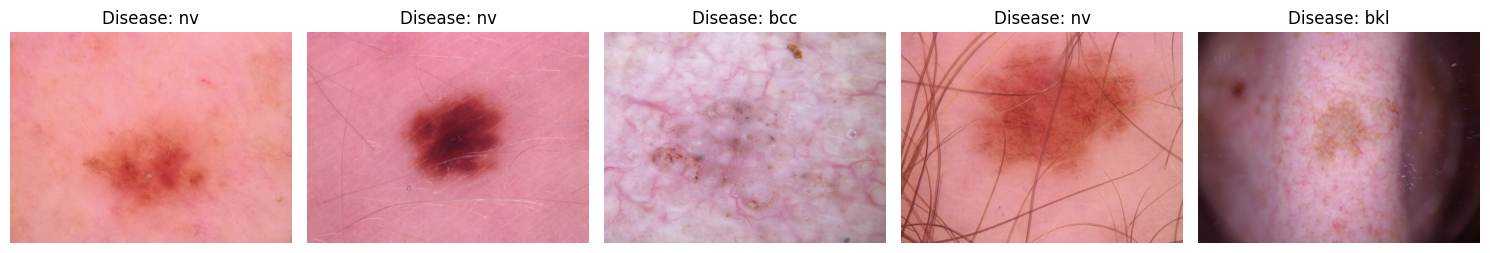

In [ ]:
##import รูป
import os
import glob
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import kagglehub

print("1. กำลังดึงข้อมูลผ่าน KaggleHub...")
# ถ้าเคยโหลดแล้ว มันจะดึงจากในเครื่องทันที ไม่ต้องรอโหลดใหม่!
dataset_path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
#print(f"ตำแหน่งที่เก็บไฟล์: {dataset_path}")

print("\n---กำลังสแกนหาไฟล์ ---")

# ค้นหาไฟล์ .csv และ .jpg แบบค้นหาลึกเข้าไปในทุกโฟลเดอร์ย่อย (recursive=True)
csv_files = glob.glob(os.path.join(dataset_path, '**', '*.csv'), recursive=True)
image_files = glob.glob(os.path.join(dataset_path, '**', '*.jpg'), recursive=True)

print(f"เจอไฟล์ CSV ทั้งหมด {len(csv_files)} ไฟล์")
print(f"เจอไฟล์รูปภาพทั้งหมด {len(image_files)} รูป")

if len(csv_files) > 0:
    # พยายามเลือกไฟล์ที่มีคำว่า 'metadata' (ตารางเฉลยหลักของ HAM10000)
    target_csv = [f for f in csv_files if 'metadata' in f.lower()]
    csv_to_read = target_csv[0] if len(target_csv) > 0 else csv_files[0]

    print(f"\n📂 กำลังเปิดอ่านไฟล์เฉลย: {os.path.basename(csv_to_read)}")
    df_skin = pd.read_csv(csv_to_read)

    print(f"📊 จำนวนรูปภาพในตาราง: {len(df_skin)} เคส")
    print("\nสัดส่วนของโรคผิวหนังแต่ละประเภท (คอลัมน์ dx):")
    print(df_skin['dx'].value_counts())

    # สุ่มรูปภาพมาแสดง 5 รูป
    if len(image_files) > 0:
        plt.figure(figsize=(15, 5))
        for i in range(5):
            random_image_path = random.choice(image_files)

            # ดึงชื่อไฟล์รูปภาพ (เช่น ISIC_0024306)
            img_name = os.path.basename(random_image_path).replace('.jpg', '')

            # หาชื่อโรคจากตาราง
            disease_code = "Unknown"
            match_row = df_skin[df_skin['image_id'] == img_name]
            if not match_row.empty:
                disease_code = match_row['dx'].values[0]

            img = mpimg.imread(random_image_path)
            plt.subplot(1, 5, i+1)
            plt.imshow(img)
            plt.title(f"Disease: {disease_code}")
            plt.axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("❌ หาไฟล์รูปภาพ .jpg ไม่เจอ")
else:
    print("❌ สแกนลึกทุกโฟลเดอร์แล้ว ก็ยังไม่เจอไฟล์ CSV ")

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

In [ ]:

image_dict = {os.path.basename(p).split('.')[0]: p for p in image_files}
df_skin['path'] = df_skin['image_id'].map(image_dict)

# ตัดแถวที่หาภาพไม่เจอทิ้งไป ป้องกัน Error ตอนเทรน
df_skin = df_skin.dropna(subset=['path'])

#แบ่งข้อมูล Train 80% / Validation 20%
train_df, val_df = train_test_split(df_skin, test_size=0.2, random_state=42, stratify=df_skin['dx'])

#  Generator และหาร 255
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True # ผิวหนังกลับหัวได้
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col="path", y_col="dx",
    target_size=(128, 128), batch_size=16, class_mode="categorical"
)
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df, x_col="path", y_col="dx",
    target_size=(128, 128), batch_size=16, class_mode="categorical"
)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

Found 8012 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.


In [ ]:
# ---- บล็อกที่ 1: รับภาพสี (128x128x3) และสกัดขอบรอยโรค ----
CNN_model = keras.Sequential()
CNN_model.add(keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(128, 128, 3)))
CNN_model.add(keras.layers.BatchNormalization())
CNN_model.add(keras.layers.MaxPooling2D((2,2)))
CNN_model.add(keras.layers.Dropout(0.1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# ---- บล็อกที่ 2: รายละเอียดพื้นผิวและสี ----
CNN_model.add(keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
CNN_model.add(keras.layers.BatchNormalization())
CNN_model.add(keras.layers.MaxPooling2D((2,2)))
CNN_model.add(keras.layers.Dropout(0.1))

In [ ]:
# ---- บล็อกที่ 3: ความซับซ้อนระดับลึก ----
CNN_model.add(keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
CNN_model.add(keras.layers.BatchNormalization())
CNN_model.add(keras.layers.MaxPooling2D((2,2)))
CNN_model.add(keras.layers.Dropout(0.2))

In [ ]:
# ---- บล็อกที่ 4: ทายผลโรค ----
CNN_model.add(keras.layers.Flatten())
CNN_model.add(keras.layers.Dense(128, activation='relu'))
CNN_model.add(keras.layers.BatchNormalization())
CNN_model.add(keras.layers.Dropout(0.5))
CNN_model.add(keras.layers.Dense(7, activation='softmax'))

In [ ]:
custom_adam = Adam(learning_rate=0.0005)

In [ ]:
CNN_model.compile(
    optimizer=custom_adam,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
CNN_model.summary()
history = CNN_model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator
)

✅ โครงสร้างเสร็จสมบูรณ์! หน้าตาของโมเดลเป็นแบบนี้ครับ:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289,991 (16.37 MB)

 Trainable params: 4,289,287 (16.36 MB)

 Non-trainable params: 704 (2.75 KB)


🔥 เริ่มทำการฝึกสอน AI (ใช้เวลาประมาณ 5-10 นาที)...
Epoch 1/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 647s 1s/step - accuracy: 0.5041 - loss: 1.5375 - val_accuracy: 0.6780 - val_loss: 1.2595
Epoch 2/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 626s 1s/step - accuracy: 0.6569 - loss: 0.9944 - val_accuracy: 0.6850 - val_loss: 0.8911
Epoch 3/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 626s 1s/step - accuracy: 0.6759 - loss: 0.9046 - val_accuracy: 0.6680 - val_loss: 1.0862
Epoch 4/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 631s 1s/step - accuracy: 0.6921 - loss: 0.8433 - val_accuracy: 0.6840 - val_loss: 0.8679
Epoch 5/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 624s 1s/step - accuracy: 0.7104 - loss: 0.8011 - val_accuracy: 0.7189 - val_loss: 0.7650
Epoch 6/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 628s 1s/step - accuracy: 0.7164 - loss: 0.7719 - val_accuracy: 0.7169 - val_loss: 0.7810
Epoch 7/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 639s 1s/step - accuracy: 0.7163 - loss: 0.7683 - val_accuracy: 0.7389 - val_loss: 0.9507
Epoch 8/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 650s 

In [ ]:
CNN_model.save('skin_cancer_model.h5')

NameError: name 'CNN_model' is not defined

In [ ]:
from google.colab import files
files.download('skin_cancer_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ กำลังเริ่มดาวน์โหลดไฟล์ลงเครื่อง... (รอสักครู่นะครับ ไฟล์อาจจะมีขนาดประมาณ 15-50 MB)
